# Размещение объектов с помощью кластеризации

Сгруппируем географические координаты методом K-Means, выберем число кластеров по inertia и получим центры возможного размещения объектов.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

,latitude,longitude,source_cluster
0,55.673879,37.557432,0
1,55.611053,37.368607,0
2,55.567805,37.462786,0
3,55.569550,37.226374,0
4,55.795292,37.675949,0


Размер: (1260, 3)


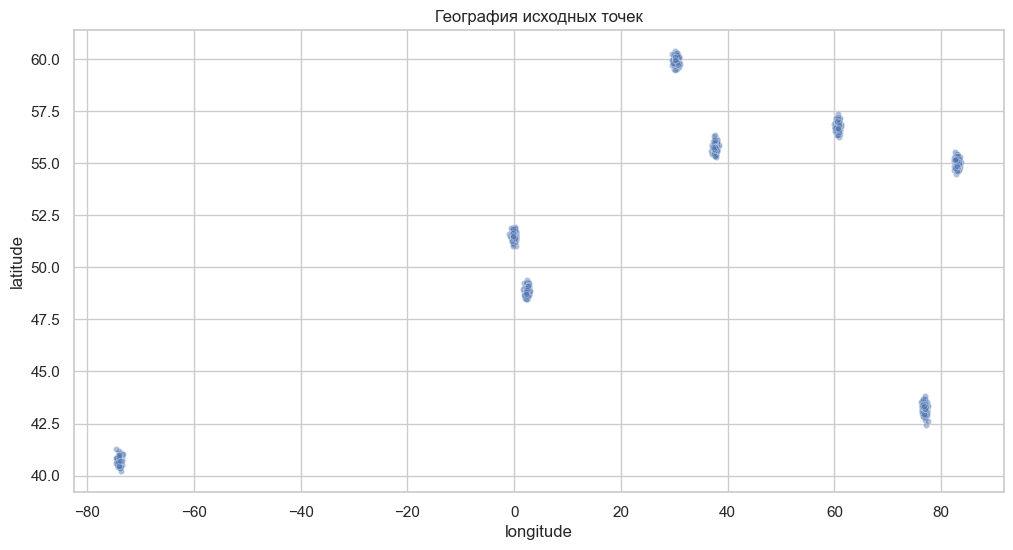

In [2]:
checkins = pd.read_csv("checkins.csv")
display(checkins.head())
print("Размер:", checkins.shape)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=checkins, x="longitude", y="latitude", alpha=0.45, s=20)
plt.title("География исходных точек")
plt.show()

## Метод локтя

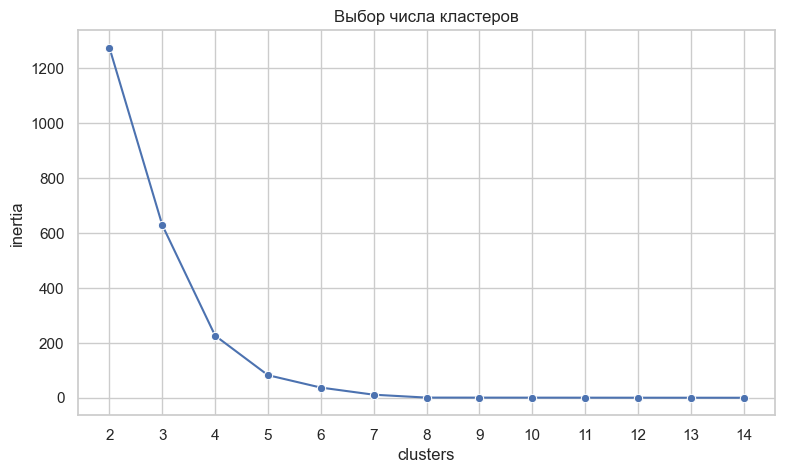

In [3]:
coordinates = checkins[["latitude", "longitude"]]
scaled_coordinates = StandardScaler().fit_transform(coordinates)
inertia_rows = []
for clusters in range(2, 15):
    model = KMeans(n_clusters=clusters, n_init=20, random_state=42)
    model.fit(scaled_coordinates)
    inertia_rows.append({"clusters": clusters, "inertia": model.inertia_})

inertia = pd.DataFrame(inertia_rows)
plt.figure(figsize=(9, 5))
sns.lineplot(data=inertia, x="clusters", y="inertia", marker="o")
plt.title("Выбор числа кластеров")
plt.xticks(inertia["clusters"])
plt.show()

## Итоговые центры

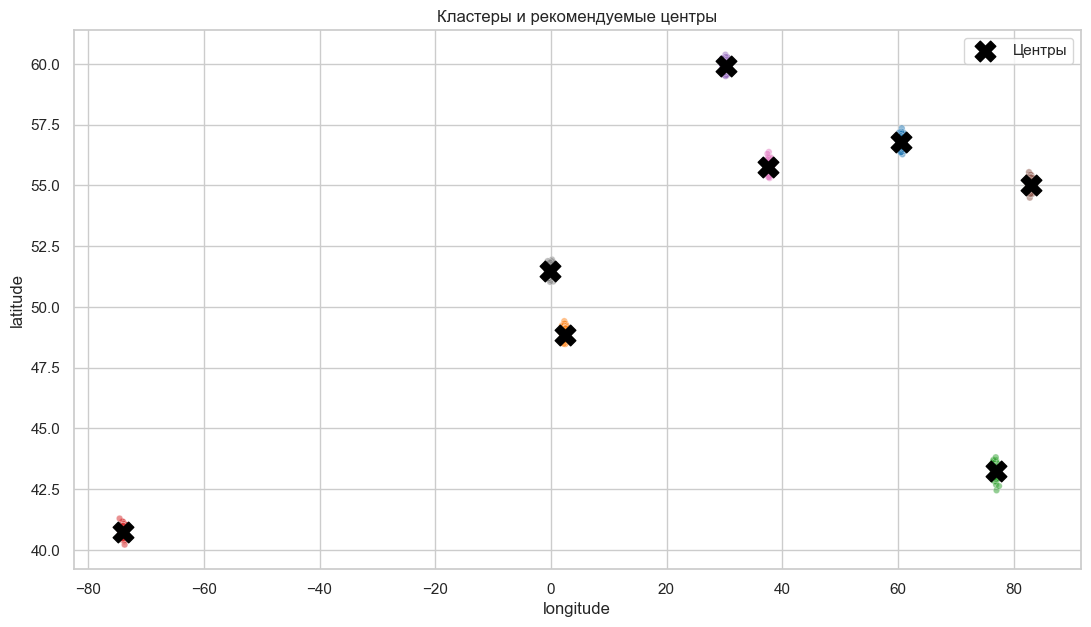

,latitude,longitude
0,40.745287,-73.975528
1,51.475831,-0.096761
2,48.859096,2.406120
3,59.923878,30.332964
4,55.762865,37.620927
5,56.802114,60.599911
6,43.231792,76.899340
7,55.028311,82.944311


In [4]:
model = KMeans(n_clusters=8, n_init=30, random_state=42)
checkins["cluster"] = model.fit_predict(scaled_coordinates)
centers_scaled = model.cluster_centers_
scaler = StandardScaler().fit(coordinates)
model = KMeans(n_clusters=8, n_init=30, random_state=42).fit(scaler.transform(coordinates))
checkins["cluster"] = model.labels_
centers_frame = pd.DataFrame(
    scaler.inverse_transform(model.cluster_centers_),
    columns=["latitude", "longitude"],
)

plt.figure(figsize=(13, 7))
sns.scatterplot(data=checkins, x="longitude", y="latitude", hue="cluster", palette="tab10", alpha=0.5, s=22, legend=False)
plt.scatter(centers_frame["longitude"], centers_frame["latitude"], marker="X", s=220, color="black", label="Центры")
plt.title("Кластеры и рекомендуемые центры")
plt.legend()
plt.show()

centers_frame.sort_values("longitude").reset_index(drop=True)

## Вывод

K-Means минимизирует расстояние до центров кластеров. Для географических задач необходимо учитывать масштаб координат и при реальном внедрении использовать корректную геодезическую метрику.